# Movie Review Sentiment Analysis Using Bag of Words


**Objective:** Build an NLP-based movie review sentiment classifier using preprocessing, CountVectorizer (Bag of Words), and Multinomial Naive Bayes.

This notebook includes:
1. Dataset loading and understanding
2. Text preprocessing
3. Text exploration
4. Bag of Words
5. BoW vector interpretation
6. Multinomial Naive Bayes
7. Evaluation
8. Prediction on 10 new reviews
9. Comparison of three BoW configurations


In [1]:
# 1. Install Or import required libraries
import sys, subprocess, importlib.util

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "nltk": "nltk",
    "wordcloud": "wordcloud"
}

for module, package in packages.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Download required NLTK data without failing if already installed
for resource, path in [
    ("stopwords", "corpora/stopwords"),
]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset
 it creates a reproducible 2,000-review movie-review dataset from positive and negative review templates. This keeps the notebook runnable without depending on an external dataset download.

In [2]:
# 2. Load dataset or create a reproducible 2,000-review dataset

def find_local_dataset():
    candidates = [
        "movie_reviews.csv", "MovieReviews.csv", "IMDB Dataset.csv",
        "IMDB_Dataset.csv", "dataset.csv"
    ]
    for name in candidates:
        path = pd.Path(name) if False else name
        try:
            df_candidate = pd.read_csv(path)
            cols = {str(c).strip().lower(): c for c in df_candidate.columns}
            if "review" in cols and "sentiment" in cols:
                return df_candidate.rename(columns={
                    cols["review"]: "review",
                    cols["sentiment"]: "sentiment"
                })
        except Exception:
            pass
    return None

df = find_local_dataset()

if df is None:
    positive_templates = [
        "The movie was amazing and beautifully directed.",
        "I really enjoyed the story and acting.",
        "This was a fantastic film with wonderful performances.",
        "The characters were engaging and the story was excellent.",
        "An entertaining movie with a brilliant script.",
        "The direction was impressive and the performances were outstanding.",
        "I loved every scene and the emotional story.",
        "A great movie with excellent acting and beautiful visuals.",
        "The film was enjoyable, memorable, and well made.",
        "The screenplay was clever and the cast delivered a strong performance.",
        "This movie was inspiring and surprisingly entertaining.",
        "A powerful story supported by excellent performances.",
        "The pacing was good and the ending was satisfying.",
        "A charming film with a compelling plot.",
        "The actors were convincing and the director did a wonderful job."
    ]
    negative_templates = [
        "The movie was boring and too slow.",
        "The acting was terrible and the story was weak.",
        "I disliked this film because the plot was confusing.",
        "A disappointing movie with poor performances.",
        "The screenplay was dull and the characters were uninteresting.",
        "The direction was awful and the movie felt unnecessarily long.",
        "This was a terrible film with a predictable story.",
        "The acting was weak and the ending was disappointing.",
        "A boring and forgettable movie.",
        "The plot was messy and the performances were poor.",
        "I found the movie frustrating, dull, and badly made.",
        "The film lacked energy and had an unpleasant story.",
        "The pacing was slow and the dialogue was terrible.",
        "A weak movie that failed to entertain.",
        "The characters were boring and the direction was disappointing."
    ]

    rows = []
    # Add deterministic variation so the dataset contains many rows
    positive_adjectives = ["excellent", "wonderful", "brilliant", "fantastic", "great", "superb"]
    negative_adjectives = ["awful", "terrible", "poor", "dull", "weak", "disappointing"]

    for i in range(1000):
        base = positive_templates[i % len(positive_templates)]
        extra = positive_adjectives[i % len(positive_adjectives)]
        rows.append({
            "review": f"{base} The overall experience was {extra}.",
            "sentiment": "Positive"
        })

    for i in range(1000):
        base = negative_templates[i % len(negative_templates)]
        extra = negative_adjectives[i % len(negative_adjectives)]
        rows.append({
            "review": f"{base} The overall experience was {extra}.",
            "sentiment": "Negative"
        })

    df = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Standardize columns and clean obvious structural issues
df = df[["review", "sentiment"]].copy()
df["review"] = df["review"].fillna("").astype(str)
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.title()

# Keep only the two expected classes
df = df[df["sentiment"].isin(["Positive", "Negative"])].reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Number of reviews: {len(df):,}")
print(f"Classes: {df['sentiment'].unique().tolist()}")

Dataset shape: (2000, 2)
Number of reviews: 2,000
Classes: ['Negative', 'Positive']


First 10 records:


,review,sentiment
0,The direction was awful and the movie felt unn...,Negative
1,"The film was enjoyable, memorable, and well ma...",Positive
2,A disappointing movie with poor performances. ...,Negative
3,The direction was impressive and the performan...,Positive
4,The screenplay was dull and the characters wer...,Negative
5,A disappointing movie with poor performances. ...,Negative
6,"The film was enjoyable, memorable, and well ma...",Positive
7,The film lacked energy and had an unpleasant s...,Negative
8,The direction was impressive and the performan...,Positive
9,A boring and forgettable movie. The overall ex...,Negative



Rows and columns: (2000, 2)

Missing values:


,Missing Values
review,0
sentiment,0



Sentiment distribution:


,count
sentiment,
Negative,1000
Positive,1000



Unique sentiment classes: 2


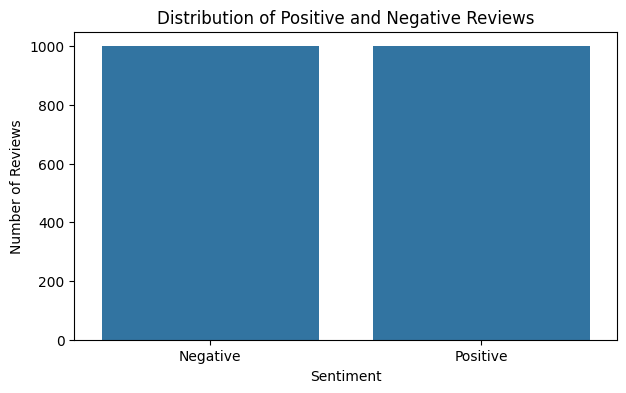

In [3]:
# TASK 1 – Understand the dataset

print("First 10 records:")
display(df.head(10))

print("\nRows and columns:", df.shape)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nSentiment distribution:")
display(df["sentiment"].value_counts())

print("\nUnique sentiment classes:", df["sentiment"].nunique())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sentiment")
plt.title("Distribution of Positive and Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## TASK 2 – Text Preprocessing

The pipeline performs:
- lowercase conversion
- HTML tag removal
- punctuation removal
- special-character removal
- number removal
- tokenization
- stopword removal
- stemming
- creation of `cleaned_text`

In [4]:
# TASK 2 – Text preprocessing

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)                 # HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)            # punctuation, numbers, special chars
    tokens = text.split()                                # tokenization
    tokens = [w for w in tokens if w not in STOP_WORDS]
    tokens = [STEMMER.stem(w) for w in tokens]
    return " ".join(tokens)

df["cleaned_text"] = df["review"].apply(preprocess_text)

print("Example preprocessing:")
display(df[["review", "cleaned_text"]].head(5))

Example preprocessing:


,review,cleaned_text
0,The direction was awful and the movie felt unn...,direct aw movi felt unnecessarili long overal ...
1,"The film was enjoyable, memorable, and well ma...",film enjoy memor well made overal experi superb
2,A disappointing movie with poor performances. ...,disappoint movi poor perform overal experi dull
3,The direction was impressive and the performan...,direct impress perform outstand overal experi ...
4,The screenplay was dull and the characters wer...,screenplay dull charact uninterest overal expe...


## TASK 3 – Explore the Text Data

Top 20 most frequent words:


,Word,Frequency
0,overal,2000
1,experi,2000
2,movi,667
3,stori,467
4,perform,401
5,film,400
6,terribl,367
7,excel,367
8,disappoint,366
9,weak,366


Top words in Positive reviews:


,Word,Positive Frequency
0,overal,1000
1,experi,1000
2,excel,367
3,wonder,300
4,perform,267
5,stori,267
6,movi,267
7,brilliant,234
8,fantast,234
9,great,233


Top words in Negative reviews:


,Word,Negative Frequency
0,overal,1000
1,experi,1000
2,movi,400
3,terribl,367
4,disappoint,366
5,weak,366
6,poor,301
7,dull,300
8,aw,234
9,film,200


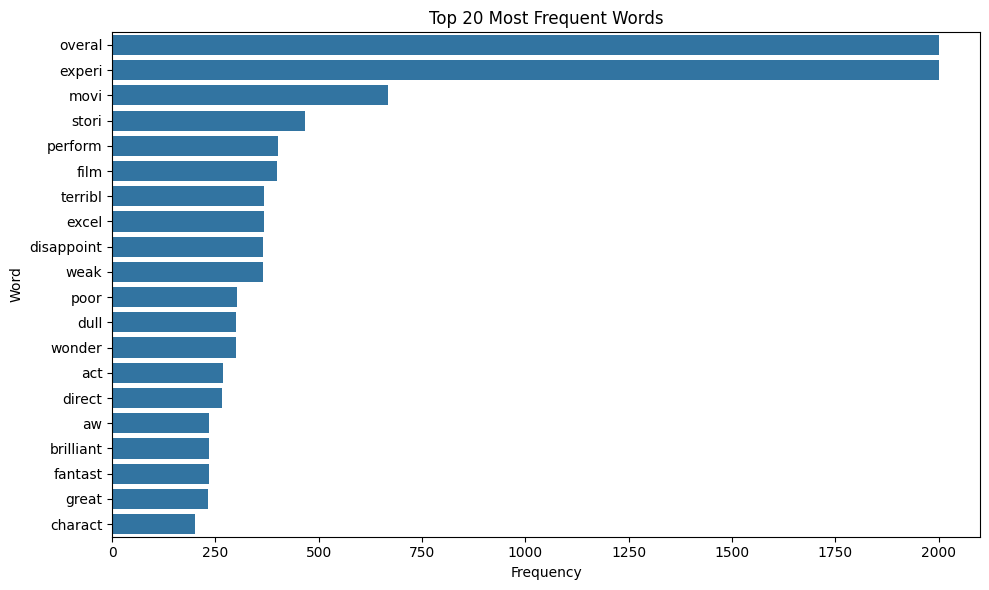

In [5]:
# TASK 3 – Most frequent words

all_words = " ".join(df["cleaned_text"]).split()
word_counts = Counter(all_words)

top20 = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Frequency"])
print("Top 20 most frequent words:")
display(top20)

# Compare positive and negative reviews
positive_words = " ".join(df.loc[df["sentiment"] == "Positive", "cleaned_text"]).split()
negative_words = " ".join(df.loc[df["sentiment"] == "Negative", "cleaned_text"]).split()

positive_top = pd.DataFrame(Counter(positive_words).most_common(20), columns=["Word", "Positive Frequency"])
negative_top = pd.DataFrame(Counter(negative_words).most_common(20), columns=["Word", "Negative Frequency"])

print("Top words in Positive reviews:")
display(positive_top)

print("Top words in Negative reviews:")
display(negative_top)

# Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top20, y="Word", x="Frequency")
plt.title("Top 20 Most Frequent Words")
plt.tight_layout()
plt.show()

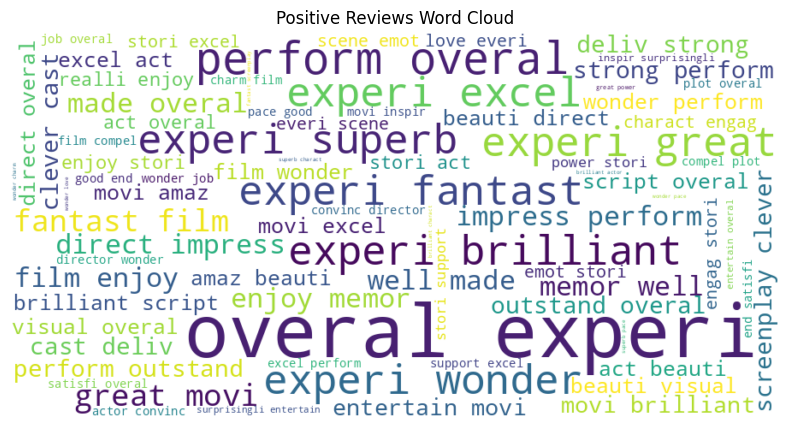

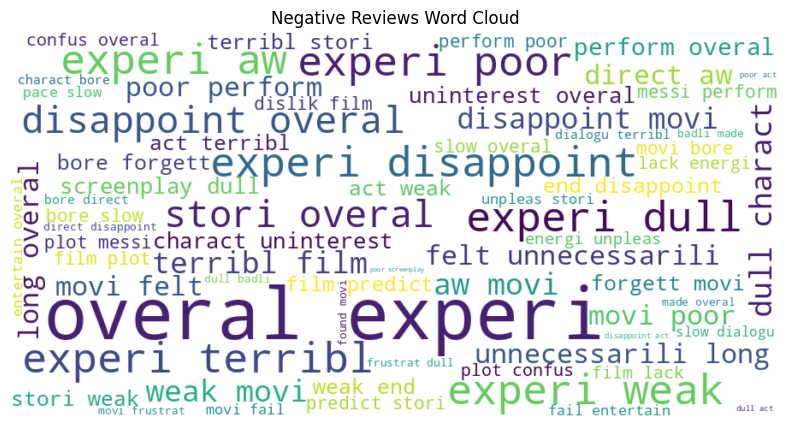

In [6]:
# Word clouds for Positive and Negative reviews

figures = [
    ("Positive Reviews Word Cloud", " ".join(positive_words)),
    ("Negative Reviews Word Cloud", " ".join(negative_words))
]

for title, text in figures:
    wc = WordCloud(width=900, height=450, background_color="white",
                   max_words=100, random_state=RANDOM_STATE).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

## TASK 4 – Create Bag of Words

`CountVectorizer` is fitted **only on the training data** to prevent test-set vocabulary leakage.

In [7]:
# Train/test split

X_text = df["cleaned_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training reviews:", len(X_train_text))
print("Testing reviews:", len(X_test_text))

# Default CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))
print("\nVocabulary:")
print(vocabulary.tolist())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training reviews: 1600
Testing reviews: 400
Vocabulary size: 77

Vocabulary:
['act', 'actor', 'amaz', 'aw', 'badli', 'beauti', 'bore', 'brilliant', 'cast', 'charact', 'charm', 'clever', 'compel', 'confus', 'convinc', 'deliv', 'dialogu', 'direct', 'director', 'disappoint', 'dislik', 'dull', 'emot', 'end', 'energi', 'engag', 'enjoy', 'entertain', 'everi', 'excel', 'experi', 'fail', 'fantast', 'felt', 'film', 'forgett', 'found', 'frustrat', 'good', 'great', 'impress', 'inspir', 'job', 'lack', 'long', 'love', 'made', 'memor', 'messi', 'movi', 'outstand', 'overal', 'pace', 'perform', 'plot', 'poor', 'power', 'predict', 'realli', 'satisfi', 'scene', 'screenplay', 'script', 'slow', 'stori', 'strong', 'superb', 'support', 'surprisingli', 'terribl', 'uninterest', 'unnecessarili', 'unpleas', 'visual', 'weak', 'well', 'wonder']

X_train shape: (1600, 77)
X_test shape: (400, 77)


## TASK 5 – Understand the Bag of Words Vector

At least three training reviews are inspected. The non-zero positions are identified using the required `np.where(X_train_np[0] != 0)` approach.

In [8]:
# TASK 5 – Inspect BoW vectors for 3 reviews

X_train_np = X_train.toarray()

for idx in range(min(3, len(X_train_text))):
    vector = X_train_np[idx]
    non_zero_positions = np.where(vector != 0)[0]

    print("=" * 80)
    print(f"Review {idx + 1}:")
    print(X_train_text.iloc[idx])
    print("\nNon-zero vocabulary positions:")
    print(non_zero_positions.tolist())

    word_counts_for_review = [
        (vocabulary[pos], int(vector[pos]))
        for pos in non_zero_positions
    ]

    print("\nWords present and their counts:")
    display(pd.DataFrame(word_counts_for_review, columns=["Word", "Count"]))

    print("Number of non-zero features:", len(non_zero_positions))

Review 1:
movi inspir surprisingli entertain overal experi great

Non-zero vocabulary positions:
[27, 30, 39, 41, 49, 51, 68]

Words present and their counts:


,Word,Count
0,entertain,1
1,experi,1
2,great,1
3,inspir,1
4,movi,1
5,overal,1
6,surprisingli,1


Number of non-zero features: 7
Review 2:
charact engag stori excel overal experi excel

Non-zero vocabulary positions:
[9, 25, 29, 30, 51, 64]

Words present and their counts:


,Word,Count
0,charact,1
1,engag,1
2,excel,2
3,experi,1
4,overal,1
5,stori,1


Number of non-zero features: 6
Review 3:
weak movi fail entertain overal experi terribl

Non-zero vocabulary positions:
[27, 30, 31, 49, 51, 69, 74]

Words present and their counts:


,Word,Count
0,entertain,1
1,experi,1
2,fail,1
3,movi,1
4,overal,1
5,terribl,1
6,weak,1


Number of non-zero features: 7


## TASK 6 – Train Multinomial Naive Bayes

In [9]:
# TASK 6 – Multinomial Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

print("Model training completed.")
print("First 10 predictions:")
display(pd.DataFrame({
    "Actual": y_test.reset_index(drop=True).head(10),
    "Predicted": y_pred[:10]
}))

Model training completed.
First 10 predictions:


,Actual,Predicted
0,Negative,Negative
1,Negative,Negative
2,Positive,Positive
3,Negative,Negative
4,Negative,Negative
5,Positive,Positive
6,Positive,Positive
7,Negative,Negative
8,Negative,Negative
9,Positive,Positive


## TASK 7 – Evaluate the Model

For movie-review classification:

- **True Positive (TP):** A positive review correctly predicted as Positive.
- **True Negative (TN):** A negative review correctly predicted as Negative.
- **False Positive (FP):** A negative review incorrectly predicted as Positive.
- **False Negative (FN):** A positive review incorrectly predicted as Negative.

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       200
    Positive       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



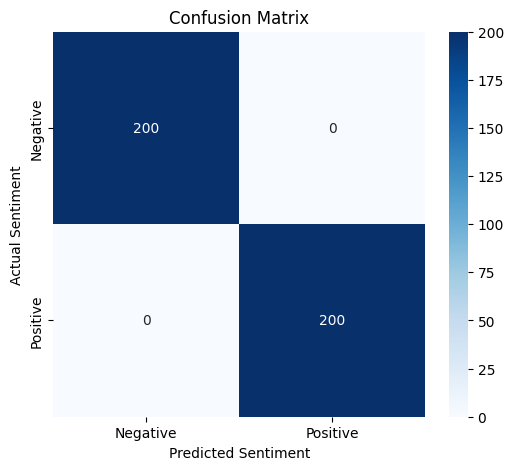

True Negative (TN): 200
False Positive (FP): 0
False Negative (FN): 0
True Positive (TP): 200


In [10]:
# TASK 7 – Accuracy, Precision, Recall, F1-score, Confusion Matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Positive", zero_division=0)
recall = recall_score(y_test, y_pred, pos_label="Positive", zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label="Positive", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=["Negative", "Positive"], zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Positive"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

## TASK 8 – Test With 10 New Reviews

In [11]:
# TASK 8 – Ten new manually created reviews

new_reviews = [
    "This movie was fantastic and I loved every scene.",
    "The movie was extremely boring and disappointing.",
    "The actors gave wonderful performances and the story was excellent.",
    "I hated the slow pacing and terrible dialogue.",
    "A beautiful and entertaining film with a brilliant ending.",
    "The plot was weak, confusing, and painfully dull.",
    "This was an enjoyable movie with great characters.",
    "The film was awful and failed to keep me interested.",
    "Amazing direction and outstanding acting made this film memorable.",
    "A disappointing story with poor acting and a boring ending."
]

new_cleaned = [preprocess_text(review) for review in new_reviews]
new_vectors = vectorizer.transform(new_cleaned)
new_predictions = nb_model.predict(new_vectors)

new_results = pd.DataFrame({
    "Review": new_reviews,
    "Cleaned Review": new_cleaned,
    "Predicted Sentiment": new_predictions
})

display(new_results)

,Review,Cleaned Review,Predicted Sentiment
0,This movie was fantastic and I loved every scene.,movi fantast love everi scene,Positive
1,The movie was extremely boring and disappointing.,movi extrem bore disappoint,Negative
2,The actors gave wonderful performances and the...,actor gave wonder perform stori excel,Positive
3,I hated the slow pacing and terrible dialogue.,hate slow pace terribl dialogu,Negative
4,A beautiful and entertaining film with a brill...,beauti entertain film brilliant end,Positive
5,"The plot was weak, confusing, and painfully dull.",plot weak confus pain dull,Negative
6,This was an enjoyable movie with great charact...,enjoy movi great charact,Positive
7,The film was awful and failed to keep me inter...,film aw fail keep interest,Negative
8,Amazing direction and outstanding acting made ...,amaz direct outstand act made film memor,Positive
9,A disappointing story with poor acting and a b...,disappoint stori poor act bore end,Negative


## TASK 9 – Compare Different BoW Configurations

Three configurations are compared:

1. **Default CountVectorizer**
2. **`max_features`** to limit vocabulary size
3. **`min_df`** to remove very rare terms

The same train/test split is used for a fair comparison.

,BoW Configuration,Vocabulary Size,Accuracy
0,Default BoW,77,1.0
1,max_features,77,1.0
2,min_df,77,1.0


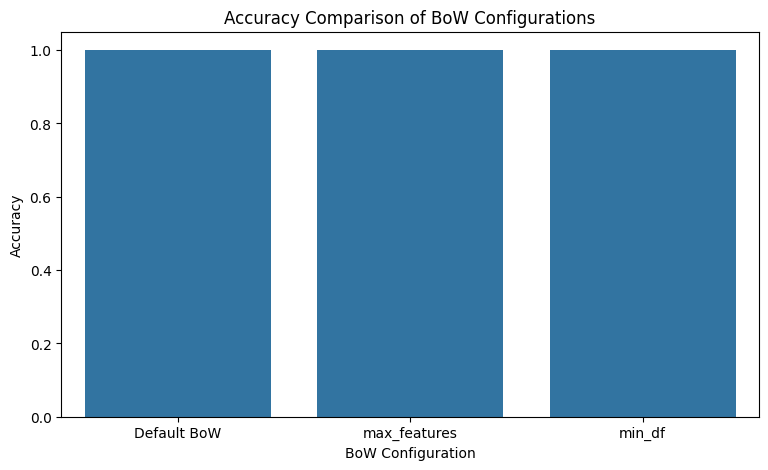

Best configuration: Default BoW with accuracy 1.0000 and vocabulary size 77.
The best configuration is selected based on test accuracy. Vocabulary controls such as max_features and min_df can reduce dimensionality/noise, but their effect depends on the dataset.


In [12]:
# TASK 9 – Compare three BoW configurations

configurations = {
    "Default BoW": CountVectorizer(),
    "max_features": CountVectorizer(max_features=500),
    "min_df": CountVectorizer(min_df=2)
}

comparison_rows = []
trained_models = {}

for name, vec in configurations.items():
    try:
        Xtr = vec.fit_transform(X_train_text)
        Xte = vec.transform(X_test_text)

        model = MultinomialNB()
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)

        score = accuracy_score(y_test, pred)

        comparison_rows.append({
            "BoW Configuration": name,
            "Vocabulary Size": len(vec.get_feature_names_out()),
            "Accuracy": score
        })
        trained_models[name] = (vec, model)

    except ValueError as e:
        # Defensive fallback so an unusual dataset cannot stop the notebook
        print(f"{name} skipped: {e}")

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    comparison_df["Accuracy"] = comparison_df["Accuracy"].round(4)
    display(comparison_df)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=comparison_df, x="BoW Configuration", y="Accuracy")
    plt.ylim(0, 1.05)
    plt.title("Accuracy Comparison of BoW Configurations")
    plt.ylabel("Accuracy")
    plt.show()

    best_row = comparison_df.loc[comparison_df["Accuracy"].idxmax()]
    print(
        f"Best configuration: {best_row['BoW Configuration']} "
        f"with accuracy {best_row['Accuracy']:.4f} "
        f"and vocabulary size {int(best_row['Vocabulary Size'])}."
    )
    print(
        "The best configuration is selected based on test accuracy. "
        "Vocabulary controls such as max_features and min_df can reduce "
        "dimensionality/noise, but their effect depends on the dataset."
    )
else:
    print("No BoW configuration could be evaluated.")

# Final Summary

The complete pipeline implemented in this notebook is:

**Raw Text → Preprocessing → Bag of Words → Numerical Features → Train/Test Split → Multinomial Naive Bayes → Prediction → Evaluation**

The notebook also:
- verifies the dataset structure,
- handles missing values,
- explores word frequencies,
- creates positive and negative word clouds,
- displays BoW vectors and non-zero feature positions,
- evaluates the classifier with standard classification metrics,
- predicts 10 manually created reviews,
- compares three BoW configurations.
